#Logistic Regression on a binary classification

##1.) Advanced Objective Function and Use Case

### 1.1) Derive the objective function for Logistic Regression using Maximum Likelihood Estimation (MLE). Do some research on the MAP technique for Logistic Regression, include your research on how this technique is different from MLE (include citations).

**Definitions**


---


* Wieghts = w
* Inputs = x
* Exepected Output = y
* Prediction Funtion f(x, w)

**Log Likelyhood**


---


1. Loss = -(expected 0)(log(f(x, w))+(expected 1)log(1-f(x, w))
2. Loss = -(y)(log(f(x, w))+(1-y)log(1-f(x, w))
3. f(x, w) = sigmoid($w^{T}$x)
4. Loss = -((y)(log(sigmoid($w^{T}$x))+(1-y)log(1-sigmoid($w^{T}$x)))
5. Loss = -((y)(log(σ($w^{T}$x))+(1-y)log(1-σ($w^{T}$x)))

**Map Techinque**


---


Map Incorperates the assumed aspects of the data to help in MLE caclulation. Used in smaller dataset cases. It brings the calculations closer to what we would expect.

*   https://www.cs.cornell.edu/courses/cs4780/2015fa/web/lecturenotes/lecturenote06.html





### 1.2) Define a machine learning problem you wish to solve using Logistic Regression. Justify why logistic regression is the best choice and compare it briefly to another linear classification model (cite your work if this other technique was not covered in class).

The Problem I will do is determin weather or not a given bank transaction is fraudulent or not.  This is a good place for Logistical regression as thier is a binary output as well as the fact that we have many difrent variable that are influencing our data

###1.3) Discuss how your dataset corresponds to the variables in your equations, highlighting any assumptions in your derivation from part 1.

**Dataset Mapping**


---


* wieghts(w) = our model witch we will change to better reduce the loss funciton
* Inputs(x) = are all the fetures/collumns in out dataset (amount, bankbalance extra)
* Expected output(y) = Binary weather or transaction was  fraud

##2.) Dataset and Advanced EDA

###2.1) Select a publicly available dataset (excluding commonly used datasets such as Titanic, Housing Prices or Iris). Provide a link to your dataset. Ensure the dataset has at least 10 features to allow for more complex analysis.

**Dataset Info**


---
1. Name:Fraud detection bank dataset 20K records binary
2. Features: 112
3. Binary detection variable


In [63]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("volodymyrgavrysh/fraud-detection-bank-dataset-20k-records-binary")

print("Path to dataset files:", path)
!cp -r "$path" /content/
path = kagglehub.dataset_download("volodymyrgavrysh/fraud-detection-bank-dataset-20k-records-binary")

print("Path to dataset files:", path)
!cp -r "$path" /content/

Using Colab cache for faster access to the 'fraud-detection-bank-dataset-20k-records-binary' dataset.
Path to dataset files: /kaggle/input/fraud-detection-bank-dataset-20k-records-binary
Using Colab cache for faster access to the 'fraud-detection-bank-dataset-20k-records-binary' dataset.
Path to dataset files: /kaggle/input/fraud-detection-bank-dataset-20k-records-binary


https://www.kaggle.com/datasets/volodymyrgavrysh/fraud-detection-bank-dataset-20k-records-binary

###2.2) Perform Exploratory Data Analysis (EDA), addressing potential multicollinearity among features. Use Variance Inflation Factor (VIF) to identify highly correlated variables and demonstrate steps to handle them.


####**EDA**

In [64]:
import pandas as pd;
df = pd.read_csv("/content/fraud-detection-bank-dataset-20k-records-binary/fraud_detection_bank_dataset.csv")
print("dataset")
df = pd.concat([df.iloc[:, :26], df.iloc[:, -1]], axis=1) # reduce runtime
df.head()

dataset


,Unnamed: 0,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,targets
0,0,9,1354,0,18,0,1,7,9,0,...,1,0,0,0,0,0,9,74,19,1
1,1,0,239,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,7,1,1
2,2,0,260,0,4,0,3,6,0,0,...,0,0,0,0,0,0,0,13,7,1
3,3,17,682,0,1,0,0,8,17,0,...,1,0,0,0,0,0,23,52,1,1
4,4,1,540,0,2,0,1,7,1,0,...,1,0,0,0,0,0,1,20,3,1


In [65]:
df['targets'].value_counts(normalize=True)

,proportion
targets,
0,0.734317
1,0.265683


* 73.4% Legitiment
* 26.5% Fruad

####**VIF**

With so many collumns thier is bound to be multicollinearity between some of them. Especially when deling with finaces a lot of infomation will be closly linked say spending and income.

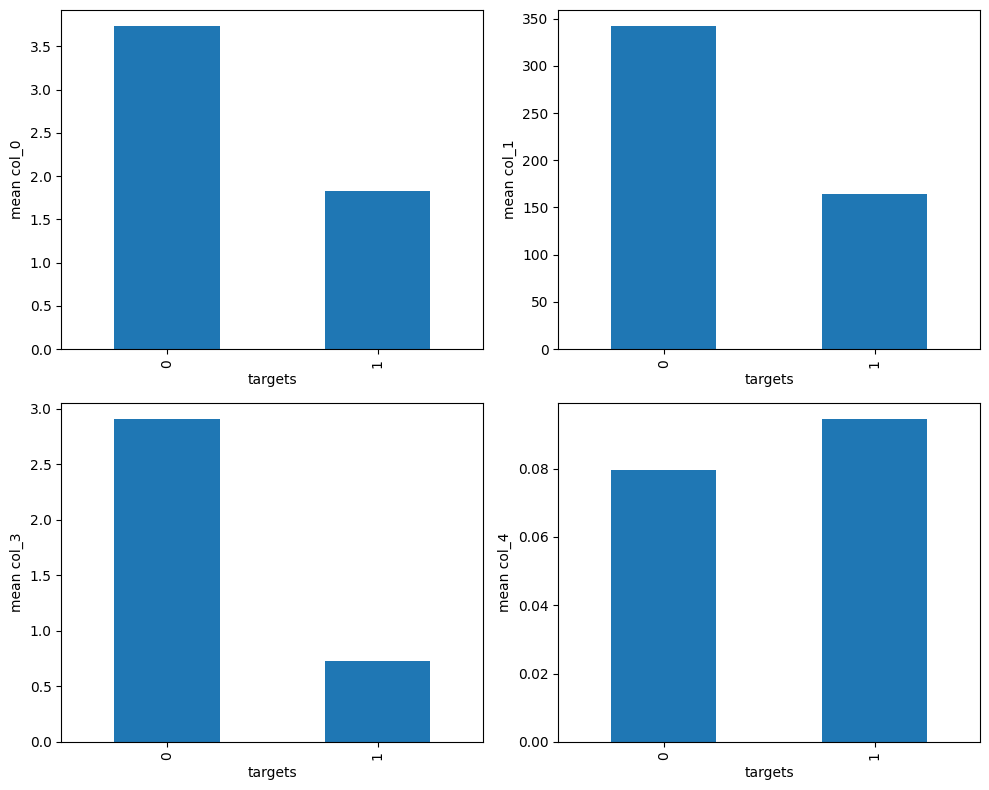

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df.groupby('targets')['col_0'].mean().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_ylabel('mean col_0')

df.groupby('targets')['col_1'].mean().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_ylabel('mean col_1')

df.groupby('targets')['col_3'].mean().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_ylabel('mean col_3')

df.groupby('targets')['col_4'].mean().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_ylabel('mean col_4')

plt.tight_layout()
plt.show()

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop(columns=['targets'])

vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

vif_df

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
0,Unnamed: 0,2.822116
1,col_0,inf
2,col_1,5.401061
3,col_2,6.109934
4,col_3,9.993958
5,col_4,1.121669
6,col_5,2.777234
7,col_6,1.505393
8,col_7,inf
9,col_8,NaN


Remove 1 collumn at a time til max corilation VIF is <5

In [68]:
import warnings
X = df.drop(columns=['targets'])
worst_score = 6
while(worst_score > 5):
  vif_df = pd.DataFrame()
  vif_df['feature'] = X.columns
  with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vif_df['VIF'] = [variance_inflation_factor(X.values, i)
                  for i in range(X.shape[1])]

  worst_feature = vif_df.loc[vif_df['VIF'].idxmax(), 'feature']
  worst_score = vif_df['VIF'].max()
  if(worst_score>5):
    X = X.drop(columns=[worst_feature])
    print(f"Worst Score: {worst_score}")
df_clean = pd.concat([X, df['targets']], axis=1)
df = df_clean

Worst Score: inf
Worst Score: 34.899037099509684
Worst Score: 17.299364423375522
Worst Score: 6.0578052449437045


###2.3) Visualize the dataset's feature relationships, ensuring inclusion of at least two advanced visualization techniques (e.g., pair plots with KDE, heatmaps with clustering).


In [69]:
df.head()

,Unnamed: 0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_13,col_14,col_15,col_16,col_17,col_18,col_19,col_20,col_21,targets
0,0,1354,0,18,0,1,7,9,0,0,...,0,1,0,1,0,0,0,0,0,1
1,1,239,0,1,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2,260,0,4,0,3,6,0,0,0,...,0,1,1,0,0,0,0,0,0,1
3,3,682,0,1,0,0,8,17,0,0,...,0,0,0,1,0,0,0,0,0,1
4,4,540,0,2,0,1,7,1,0,0,...,0,1,0,1,0,0,0,0,0,1


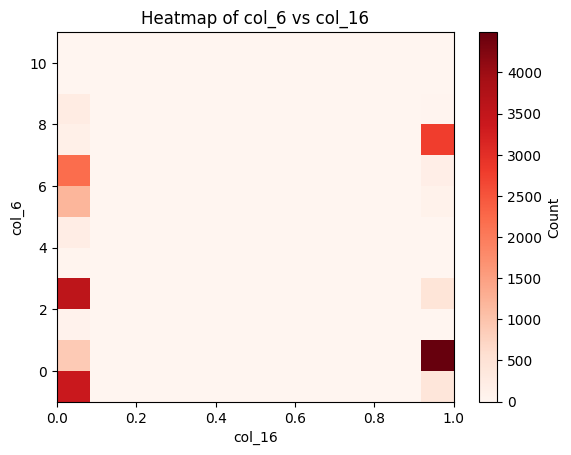

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x = df['col_16']
y = df['col_6']

plt.hist2d(x, y, bins=12, cmap='Reds')
plt.colorbar(label='Count')
plt.xlabel('col_16')
plt.ylabel('col_6')
plt.title('Heatmap of col_6 vs col_16')
plt.show()

<Figure size 800x600 with 0 Axes>

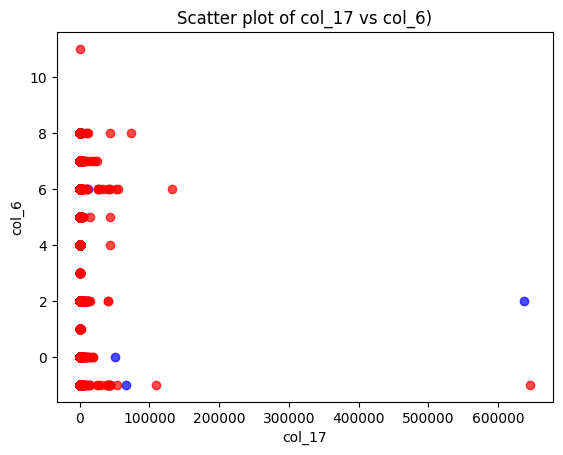

<Figure size 800x600 with 0 Axes>

In [71]:
x = df['col_17']
y = df['col_6']
targets = df["targets"]

plt.scatter(x[targets == True], y[targets == True], color='blue', label='True', alpha=0.7)

plt.scatter(x[targets == False], y[targets == False], color='red', label='False', alpha=0.7)

plt.xlabel('col_17')
plt.ylabel('col_6')
plt.title('Scatter plot of col_17 vs col_6)')
plt.figure(figsize=(8,6))


<Figure size 800x600 with 0 Axes>

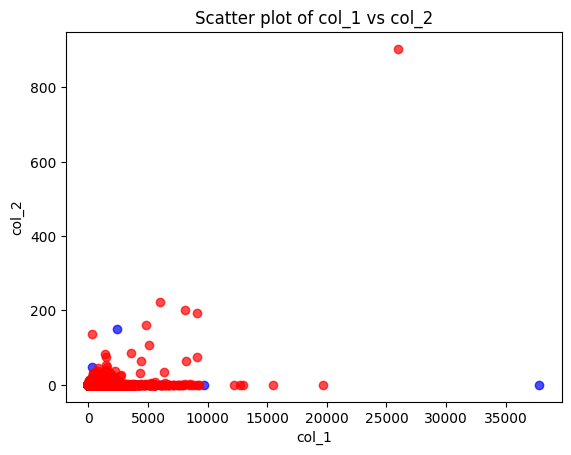

<Figure size 800x600 with 0 Axes>

In [72]:
x = df['col_1']
y = df['col_2']
targets = df["targets"]

plt.scatter(x[targets == True], y[targets == True], color='blue', label='True', alpha=0.7)

plt.scatter(x[targets == False], y[targets == False], color='red', label='False', alpha=0.7)

plt.xlabel('col_1')
plt.ylabel('col_2')
plt.title('Scatter plot of col_1 vs col_2')
plt.figure(figsize=(8,6))

##3.) Logistic Regression Implementation


###3.1) Implement Logistic Regression from scratch, including the vectorized implementation of cost function and gradient descent.

####BATCH Gradient Dencent



In [73]:
import numpy as np
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [74]:
def loss(x, y, output):
    return -(y*np.log(output+1e-12) + (1-y)*np.log(1-output+1e-12)).mean()

In [75]:
def gradient(x, y, output):
    d_output = (output - y)
    d_wieghts = (x.T @ d_output) / x.shape[0]
    d_base = d_output.mean()
    return d_wieghts, d_base

In [76]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def batch_Logistic(df, lr, steps):
  gradLoss = []

  X = df.drop(columns=['targets'])
  y = df['targets']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  n, d = X_train.shape
  w = np.zeros(d)
  b = 0.0

  for t in range(steps):
      output = sigmoid(X_train @ w + b)
      l = loss(X_train, y_train, output)
      dw, db = gradient(X_train, y_train, output)

      w -= lr * dw
      b -= lr * db
      gradLoss.append(l)
      if t % 20 == 0:
          print(f"step {t:3d} | loss {l:.4f}")

  test_probs = sigmoid(X_test @ w + b)
  test_pred = (test_probs >= 0.5).astype(int)
  acc = (test_pred == y_test).mean()
  print("Test accuracy (from scratch):", round(float(acc), 4))
  TP = np.sum((y_test == 1) & (test_pred == 1))
  TN = np.sum((y_test == 0) & (test_pred == 0))
  FP = np.sum((y_test == 0) & (test_pred == 1))
  FN = np.sum((y_test == 1) & (test_pred == 0))
  persition = TP/(TP+FP)
  recall = TP/(TP+FN)
  f1_score =2*persition*recall/(persition+recall)
  return gradLoss, acc, persition, recall, f1_score
gradLoss, acc, persition, recall, f1_score = batch_Logistic(df, .1, 101)

step   0 | loss 0.6931
step  20 | loss 0.4603
step  40 | loss 0.3644
step  60 | loss 0.3123
step  80 | loss 0.2790
step 100 | loss 0.2555
Test accuracy (from scratch): 0.9541


###3.2) Implement and compare the three gradient descent variants (e.g., batch gradient descent, stochastic gradient descent, and mini-batch gradient descent). Explain their convergence properties with respect to your cost function.

####Stochastic Gradient Descent

In [77]:
def sgradient(x, y, output):
    d_output = output - y
    d_weights = x * d_output
    d_bias = d_output
    return d_weights, d_bias

In [78]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def stochastic_Logistic(df, lr, steps):
  stocasticloss = []

  X = df.drop(columns=['targets'])
  y = df['targets']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  y_train = y_train.values
  y_test = y_test.values

  n, d = X_train.shape
  w = np.zeros(d)
  b = 0.0

  for t in range(steps):
    l = 0
    for i in range(X_train.shape[0]):
      output = sigmoid(X_train[i] @ w + b)
      l += loss(X_train[i], y_train[i], output)/X_train.shape[0]
      dw, db = sgradient(X_train[i], y_train[i], output)

      w -= lr * dw
      b -= lr * db
    stocasticloss.append(l)
    if t % 20 == 0:
        print(f"step {t:3d} | loss {l:.4f}")

  test_probs = sigmoid(X_test @ w + b)
  test_pred = (test_probs >= 0.5).astype(int)
  stoc_acc = (test_pred == y_test).mean()
  print("Test accuracy (from scratch):", round(float(stoc_acc), 4))
  TP = np.sum((y_test == 1) & (test_pred == 1))
  TN = np.sum((y_test == 0) & (test_pred == 0))
  FP = np.sum((y_test == 0) & (test_pred == 1))
  FN = np.sum((y_test == 1) & (test_pred == 0))
  persition = TP/(TP+FP)
  recall = TP/(TP+FN)
  f1_score =2*persition*recall/(persition+recall)
  return stocasticloss, stoc_acc, persition, recall, f1_score
stocasticloss, stoc_acc, stoc_per, stoc_rec, stoc_f1 = stochastic_Logistic(df, .1, 101)

step   0 | loss 0.0716
step  20 | loss 0.0200
step  40 | loss 0.0126
step  60 | loss 0.0114
step  80 | loss 0.0106
step 100 | loss 0.0100
Test accuracy (from scratch): 0.9983


####Mini-batch gradient descen

In [79]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def mini_Logistic(df, lr, steps):
  minibatchloss = []

  X = df.drop(columns=['targets'])
  y = df['targets']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  n, d = X_train.shape
  w = np.zeros(d)
  b = 0.0
  batch_size = 100
  i = np.random.randint(len(X_train)-batch_size)

  for t in range(steps):
    l=0
    for i in range(int(X_train.shape[0]/batch_size)):
      x_batch = X_train[i:i+batch_size]
      y_batch = y_train[i:i+batch_size]
      output = sigmoid(x_batch @ w + b)
      l += loss(x_batch, y_batch, output)/(X_train.shape[0]/batch_size)
      dw, db = gradient(x_batch, y_batch, output)

      w -= lr * dw
      b -= lr * db
    minibatchloss.append(l)
    if t % 20 == 0:
        print(f"step {t:3d} | loss {l:.4f}")

  test_probs = sigmoid(X_test @ w + b)
  test_pred = (test_probs >= 0.5).astype(int)
  mini_acc = (test_pred == y_test).mean()
  print("Test accuracy (from scratch):", round(float(mini_acc), 4))
  TP = np.sum((y_test == 1) & (test_pred == 1))
  TN = np.sum((y_test == 0) & (test_pred == 0))
  FP = np.sum((y_test == 0) & (test_pred == 1))
  FN = np.sum((y_test == 1) & (test_pred == 0))
  persition = TP/(TP+FP)
  recall = TP/(TP+FN)
  f1_score =2*persition*recall/(persition+recall)
  return minibatchloss, mini_acc, persition, recall, f1_score
minibatchloss, mini_acc, mini_per, mini_rec, mini_f1 = mini_Logistic(df, .1, 101)

step   0 | loss 0.3071
step  20 | loss 0.0499
step  40 | loss 0.0359
step  60 | loss 0.0294
step  80 | loss 0.0255
step 100 | loss 0.0228
Test accuracy (from scratch): 0.9861


####Comparison

In [80]:
print("Accuracys:")
print(f"Batch-{round(float(acc), 4)*100}%")
print(f"Stocastic-{round(float(stoc_acc), 4)*100}%")
print(f"Mini Batch-{round(float(mini_acc), 4)*100}%")

Accuracys:
Batch-95.41%
Stocastic-99.83%
Mini Batch-98.61%


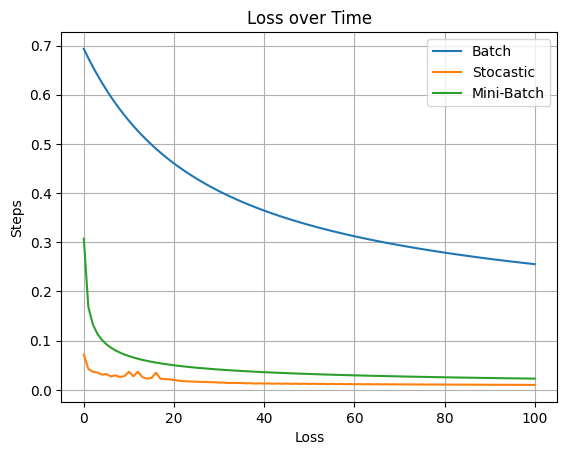

In [81]:
x = np.arange(0, 101)

plt.plot(x, gradLoss, label="Batch")
plt.plot(x, stocasticloss, label="Stocastic")
plt.plot(x, minibatchloss, label="Mini-Batch")

plt.xlabel("Loss")
plt.ylabel("Steps")
plt.title("Loss over Time")
plt.legend()
plt.grid(True)

plt.show()

Batch gradient decent is the worst out of all of them converging around .2. Stocastic and mini-Batch converge closer to .0. While Stocastic converges in the least amount of steps it also takes much longer to train per step than the other to gradient decent methods.

##4.)Optimization Techniques and Advanced Comparison

###4.1) Implement or use packages to incorporate any three optimization algorithms (e.g., Momentum, RMSProp, Adam). Compare their performance with the vanilla stochastic gradient descent implementation from Task 3.

####Momentum

In [82]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def momentum_Logistic(df, lr, steps):
  momentumLoss = []

  X = df.drop(columns=['targets'])
  y = df['targets']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  n, d = X_train.shape
  w = np.zeros(d)
  delta_w = np.zeros(d)
  delta_b = 0
  momentum = .5
  b = 0.0


  for t in range(steps):
      output = sigmoid(X_train @ w + b)
      l = loss(X_train, y_train, output)
      dw, db = gradient(X_train, y_train, output)

      delta_w = (momentum * delta_w + dw)
      delta_b = (momentum * delta_b + db)

      w -= lr * delta_w
      b -= lr * delta_b
      momentumLoss.append(l)

      if t % 20 == 0:
          print(f"step {t:3d} | loss {l:.4f}")

  test_probs = sigmoid(X_test @ w + b)
  test_pred = (test_probs >= 0.5).astype(int)
  mom_acc = (test_pred == y_test).mean()
  print("Test accuracy (from scratch):", round(float(mom_acc), 4))
  TP = np.sum((y_test == 1) & (test_pred == 1))
  TN = np.sum((y_test == 0) & (test_pred == 0))
  FP = np.sum((y_test == 0) & (test_pred == 1))
  FN = np.sum((y_test == 1) & (test_pred == 0))
  persition = TP/(TP+FP)
  recall = TP/(TP+FN)
  f1_score =2*persition*recall/(persition+recall)
  return momentumLoss, mom_acc, persition, recall, f1_score
momentumLoss, mom_acc, mom_per, mom_rec, mom_f1  = momentum_Logistic(df, .1, 101)

step   0 | loss 0.6931
step  20 | loss 0.3644
step  40 | loss 0.2773
step  60 | loss 0.2363
step  80 | loss 0.2112
step 100 | loss 0.1937
Test accuracy (from scratch): 0.9629


####Adagrad

In [83]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def agrad_Logistic(df, lr, steps):
  adagradLoss = []

  X = df.drop(columns=['targets'])
  y = df['targets']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  n, d = X_train.shape
  w = np.zeros(d)
  G_w = np.ones(d)
  G_b = 1
  b = 0.0


  for t in range(steps):
      output = sigmoid(X_train @ w + b)
      l = loss(X_train, y_train, output)
      dw, db = gradient(X_train, y_train, output)

      G_w += dw**2
      G_b += db**2

      w -= lr * dw/np.sqrt(G_w)
      b -= lr * db/np.sqrt(G_b)
      adagradLoss.append(l)

      if t % 20 == 0:
          print(f"step {t:3d} | loss {l:.4f}")

  test_probs = sigmoid(X_test @ w + b)
  test_pred = (test_probs >= 0.5).astype(int)
  add_acc = (test_pred == y_test).mean()
  print("Test accuracy (from scratch):", round(float(add_acc), 4))
  TP = np.sum((y_test == 1) & (test_pred == 1))
  TN = np.sum((y_test == 0) & (test_pred == 0))
  FP = np.sum((y_test == 0) & (test_pred == 1))
  FN = np.sum((y_test == 1) & (test_pred == 0))
  persition = TP/(TP+FP)
  recall = TP/(TP+FN)
  f1_score =2*persition*recall/(persition+recall)
  return adagradLoss, add_acc, persition, recall, f1_score
adagradLoss, add_acc, add_per, add_rec, add_f1  = agrad_Logistic(df, .1, 101)

step   0 | loss 0.6931
step  20 | loss 0.4933
step  40 | loss 0.4126
step  60 | loss 0.3656
step  80 | loss 0.3339
step 100 | loss 0.3105
Test accuracy (from scratch): 0.945


####Learning decay

In [84]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def decay_Logistic(df, lr, lr_decay, steps):
  lrDecayLoss = []
  X = df.drop(columns=['targets'])
  y = df['targets']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  n, d = X_train.shape
  w = np.zeros(d)
  b = 0.0

  for t in range(steps):
      output = sigmoid(X_train @ w + b)
      l = loss(X_train, y_train, output)
      dw, db = gradient(X_train, y_train, output)

      w -= lr * dw
      b -= lr * db
      lrDecayLoss.append(l)
      lr/=lr_decay
      if t % 20 == 0:
          print(f"step {t:3d} | loss {l:.4f}")

  test_probs = sigmoid(X_test @ w + b)
  test_pred = (test_probs >= 0.5).astype(int)
  decay_acc = (test_pred == y_test).mean()
  print("Test accuracy (from scratch):", round(float(decay_acc), 4))
  TP = np.sum((y_test == 1) & (test_pred == 1))
  TN = np.sum((y_test == 0) & (test_pred == 0))
  FP = np.sum((y_test == 0) & (test_pred == 1))
  FN = np.sum((y_test == 1) & (test_pred == 0))
  persition = TP/(TP+FP)
  recall = TP/(TP+FN)
  f1_score =2*persition*recall/(persition+recall)
  return lrDecayLoss, decay_acc, persition, recall, f1_score
lrDecayLoss, decay_acc, dec_per, dec_rec, dec_f1  = decay_Logistic(df, .2, 1.05, 101)

step   0 | loss 0.6931
step  20 | loss 0.4222
step  40 | loss 0.3782
step  60 | loss 0.3650
step  80 | loss 0.3604
step 100 | loss 0.3587
Test accuracy (from scratch): 0.9441


####Comparason

In [85]:
print("Accuracys:")
print(f"Batch-{round(float(acc), 4)*100}%")
print(f"Stocastic-{round(float(stoc_acc), 4)*100}%")
print(f"Mini Batch-{round(float(mini_acc), 4)*100}%")
print(f"Momentum-{round(float(mom_acc), 4)*100}%")
print(f"Adagrad-{round(float(add_acc), 4)*100}%")
print(f"Learing Decay-{round(float(decay_acc), 4)*100}%")

Accuracys:
Batch-95.41%
Stocastic-99.83%
Mini Batch-98.61%
Momentum-96.28999999999999%
Adagrad-94.5%
Learing Decay-94.41000000000001%


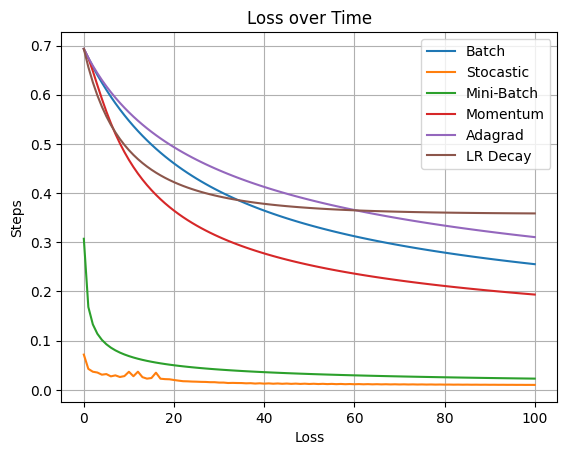

In [86]:
x = np.arange(0, 101)

plt.plot(x, gradLoss, label="Batch")
plt.plot(x, stocasticloss, label="Stocastic")
plt.plot(x, minibatchloss, label="Mini-Batch")
plt.plot(x, momentumLoss, label="Momentum")
plt.plot(x, adagradLoss, label="Adagrad")
plt.plot(x, lrDecayLoss, label="LR Decay")

plt.xlabel("Loss")
plt.ylabel("Steps")
plt.title("Loss over Time")
plt.legend()
plt.grid(True)

plt.show()

Learning rate decay is the most intresting as I gave it a higher initial learning rate and it seemed to preform much better in the begining with a higher lr. Sugjesting my lr is mutch to low.

###4.2) Define and use multiple evaluation metrics (e.g., precision, recall, F1 score) to analyze and interpret results for each algorithm.


####Defitions

* Persition= TP/(TP+FP)
* Recall = TP/(TP+FN)
* F1-Score = 2(Recall*Persition)/(Recall+Persition)


####Persition

In [87]:
print("Persition:")
print(f"Batch-{round(float(persition), 4)}")
print(f"Stocastic-{round(float(stoc_per), 4)}")
print(f"Mini Batch-{round(float(mini_per), 4)}")
print(f"Momentum-{round(float(mom_per), 4)}")
print(f"Adagrad-{round(float(add_per), 4)}")
print(f"Learing Decay-{round(float(dec_per), 4)}")

Persition:
Batch-0.8653
Stocastic-0.9963
Mini Batch-0.9657
Momentum-0.8881
Adagrad-0.8599
Learing Decay-0.8417


####Recall

In [88]:
print("Recall:")
print(f"Batch-{round(float(recall), 4)}")
print(f"Stocastic-{round(float(stoc_rec), 4)}")
print(f"Mini Batch-{round(float(mini_rec), 4)}")
print(f"Momentum-{round(float(mom_rec), 4)}")
print(f"Adagrad-{round(float(add_rec), 4)}")
print(f"Learing Decay-{round(float(dec_rec), 4)}")

Recall:
Batch-0.9798
Stocastic-0.9972
Mini Batch-0.9825
Momentum-0.9844
Adagrad-0.9476
Learing Decay-0.9724


####F1-Score

In [89]:
print("F1-Score:")
print(f"Batch-{round(float(f1_score), 4)}")
print(f"Stocastic-{round(float(stoc_f1), 4)}")
print(f"Mini Batch-{round(float(mini_f1), 4)}")
print(f"Momentum-{round(float(mom_f1), 4)}")
print(f"Adagrad-{round(float(add_f1), 4)}")
print(f"Learing Decay-{round(float(dec_f1), 4)}")

F1-Score:
Batch-0.919
Stocastic-0.9968
Mini Batch-0.974
Momentum-0.9337
Adagrad-0.9016
Learing Decay-0.9023


###4.3)Perform a hyperparameter tuning process (manual or automated using grid search/random search) for each optimization algorithm and assess its impact on performance. If you have to do some research for these techniques, please cite your sources.

In [90]:
import contextlib
import os
#go up and down till finding optimal learning rate
def hyperPreformanceTuner(function):
  print(f"{function.__name__} loss change")
  lr = .1
  steps = 100
  for i in range(41):

    with contextlib.redirect_stdout(open(os.devnull, 'w')):
      loss_neg = function(df, lr*(6/7), steps)[0][-1]
      loss_pos = function(df, lr*(7/6), steps)[0][-1]
    if(loss_neg<loss_pos):
      lr = lr*(6/7)
    else:
      lr = lr*(7/6)
    if(i%10 == 0):
      print(f"{i}: {lr}")

def dechyperPreformanceTuner(function):
  print(f"{function.__name__} loss change")
  lr = .1
  steps = 100
  for i in range(41):

    with contextlib.redirect_stdout(open(os.devnull, 'w')):
      loss_neg = function(df, lr*(15/16), 1.05, steps)[0][-1]
      loss_pos = function(df, lr*(16/15), 1.05, steps)[0][-1]
    if(loss_neg<loss_pos):
      lr = lr*(15/16)
    else:
      lr = lr*(16/15)
    if(i%10 == 0):
      print(f"{i}: {lr}")

In [91]:
hyperPreformanceTuner(batch_Logistic)

batch_Logistic loss change
0: 0.11666666666666668
10: 0.5450228193141682
20: 2.546141773484266
30: 11.894617437925461
40: 55.56718226298516


In [ ]:
hyperPreformanceTuner(stochastic_Logistic)

stochastic_Logistic loss change
0: 0.11666666666666668


In [ ]:
hyperPreformanceTuner(mini_Logistic)

In [ ]:
hyperPreformanceTuner(agrad_Logistic)

In [ ]:
hyperPreformanceTuner(momentum_Logistic)

In [ ]:
dechyperPreformanceTuner(decay_Logistic)

###4.4)Conclude by discussing the practical trade-offs of the algorithms, including computational complexity, interpretability, and suitability for large-scale datasets.

The best preformace came from Stocastic decent and Minibatching. However Stocastic decent was far and away the most timecosuming model. Minibatching in my oppinion gives the most improvement given runtime.  

  The fancyier 3 models from problem 4 actually preformed realitvy similar to the original batching problem.
  
  With Adagrad actualy preforming worse. I assume this due to its decreasing in the learning rate. From 4.3 it appears the higher the learning rate the better for thies models.
  
  All the functions had better recalls than persition. The F1-score was usialy somewere in the middle.

  Minibatching was the most optimal due to it having much quicker gradient movment with smaller batches taking less time while also not changing the gradient so much that that starts affecting runtime like in Stocastic decent.

